In [1]:
%cd ..
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


In [2]:
D_list = [
    (0.10, 0.30),
    (0.50, 0.10),
    (1.50, 0.15),
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20),
]

simulation_config = {
    "nparticles": 12,
    "nframes": 100,
    "nposframe": 5,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 700, # nphotons
    "intensity_std": 300,
}

image_config = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajectories_GT = sim.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
video_aniso = sim.video

In [14]:
animate_video(video_aniso, interval=100)

In [16]:
save_video_as_gif(video_aniso, "demo_100.gif")

# 2. Diffusion coefficient estimation

### 2.0 $ D_{GT} $

In [3]:
print_traj_params(trajectories_GT)

### 2.1 $ D_{HR} $

In [4]:
results_HR = estimateDfromTrajectories(trajectories_HR)
print_traj_params(trajectories_HR)

### 2.2 $ D_{FR} $

In [5]:
results_FR = estimateDfromTrajectories(trajectories_GT)
print_traj_params(trajectories_GT)

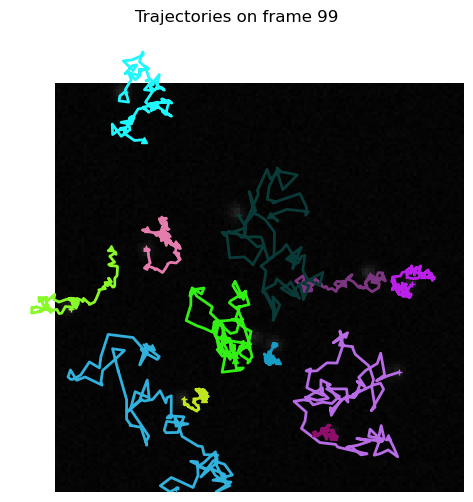

In [7]:
show_trajectories(frames, trajectories_GT, frame_id=simulation_config["nframes"]-1)

### 2.3 $ D_{detection} $

In [8]:
# define custom cost function for peak-to-peak assignment: separate weights between distance, intensity and sigma
peak2peak_cost = PeakToPeak(
    terms={
        "distance": DistanceTerm(weight=0.5, norm=image_config["output_size"]/10),
        "intensity": IntensityTerm(weight=0.5, norm=image_config["particle_intensity"][0]+image_config["particle_intensity"][1]),
    }
)

# define custom cost function for trajectory-to-trajectory assignment: fully weighted on distance between trajectories
traj_cost = TrajToTraj(
    terms={
        "position": MeanPositionDistanceTerm(weight=0.8, norm=1.0),
        "length": LengthDifferenceTerm(weight=0.1, norm=10),
        "start_frame": StartFrameDifferenceTerm(weight=0.1, norm=5),
    }
)

### 2.4 $ D_{localization} $

In [9]:
# define custom cost with chosen terms and weights
custom_cost = PeakToPeak(
    terms={
        "distance": DistanceTerm(weight=1.0, norm=5),
        "intensity": IntensityTerm(weight=0.25, norm=650),
    }
)

In [13]:
trajectories_localization, cost_peaks_to_trajectories, assignment_localization, cost_GT_assignment = track(
    frames,
    trajectories_GT,
    max_distance=10,
    min_length=5,
    detection_threshold=None,
    algo_peak2peak='hungarian',
    algo_traj2traj='hungarian',
    cost_function=custom_cost,
    verbose_loc=True,
    visualization_loc=True,
    verbose_assignment=True
)

TypeError: track() got an unexpected keyword argument 'cost_function'

In [ ]:
print(f"=> Localized {len(trajectories_localization)} trajectories.")
# print number of trajectories reassined to GT trajectories
n_reassigned = sum(1 for traj in trajectories_localization if traj.id != -1)
print(f"=> Reassigned {n_reassigned} trajectories to GT trajectories.")

=> Localized 11 trajectories.
=> Reassigned 8 trajectories to GT trajectories.


## 3. MSD Calculation

In [ ]:
calculateMSDtrajectories(trajectories_localization)
MAE_D1_loc, MAE_D2_loc = compute_tensor_MAE(
    trajectories_localization,
    trajectories_GT,
)

localization D1:
['0.075', '0.516', '0.205', '5.988', '0.378', '2.201', '0.131', '3.012']
localization D2:
['0.051', '0.124', '0.012', '0.227', '0.190', '1.281', '0.068', '1.556']
MAE D1:
['0.025', '0.016', '0.105', '1.988', '0.122', '1.799', '0.031', '0.988']
MAE D2:
['0.049', '0.376', '0.088', '3.773', '0.310', '2.719', '0.032', '2.444']


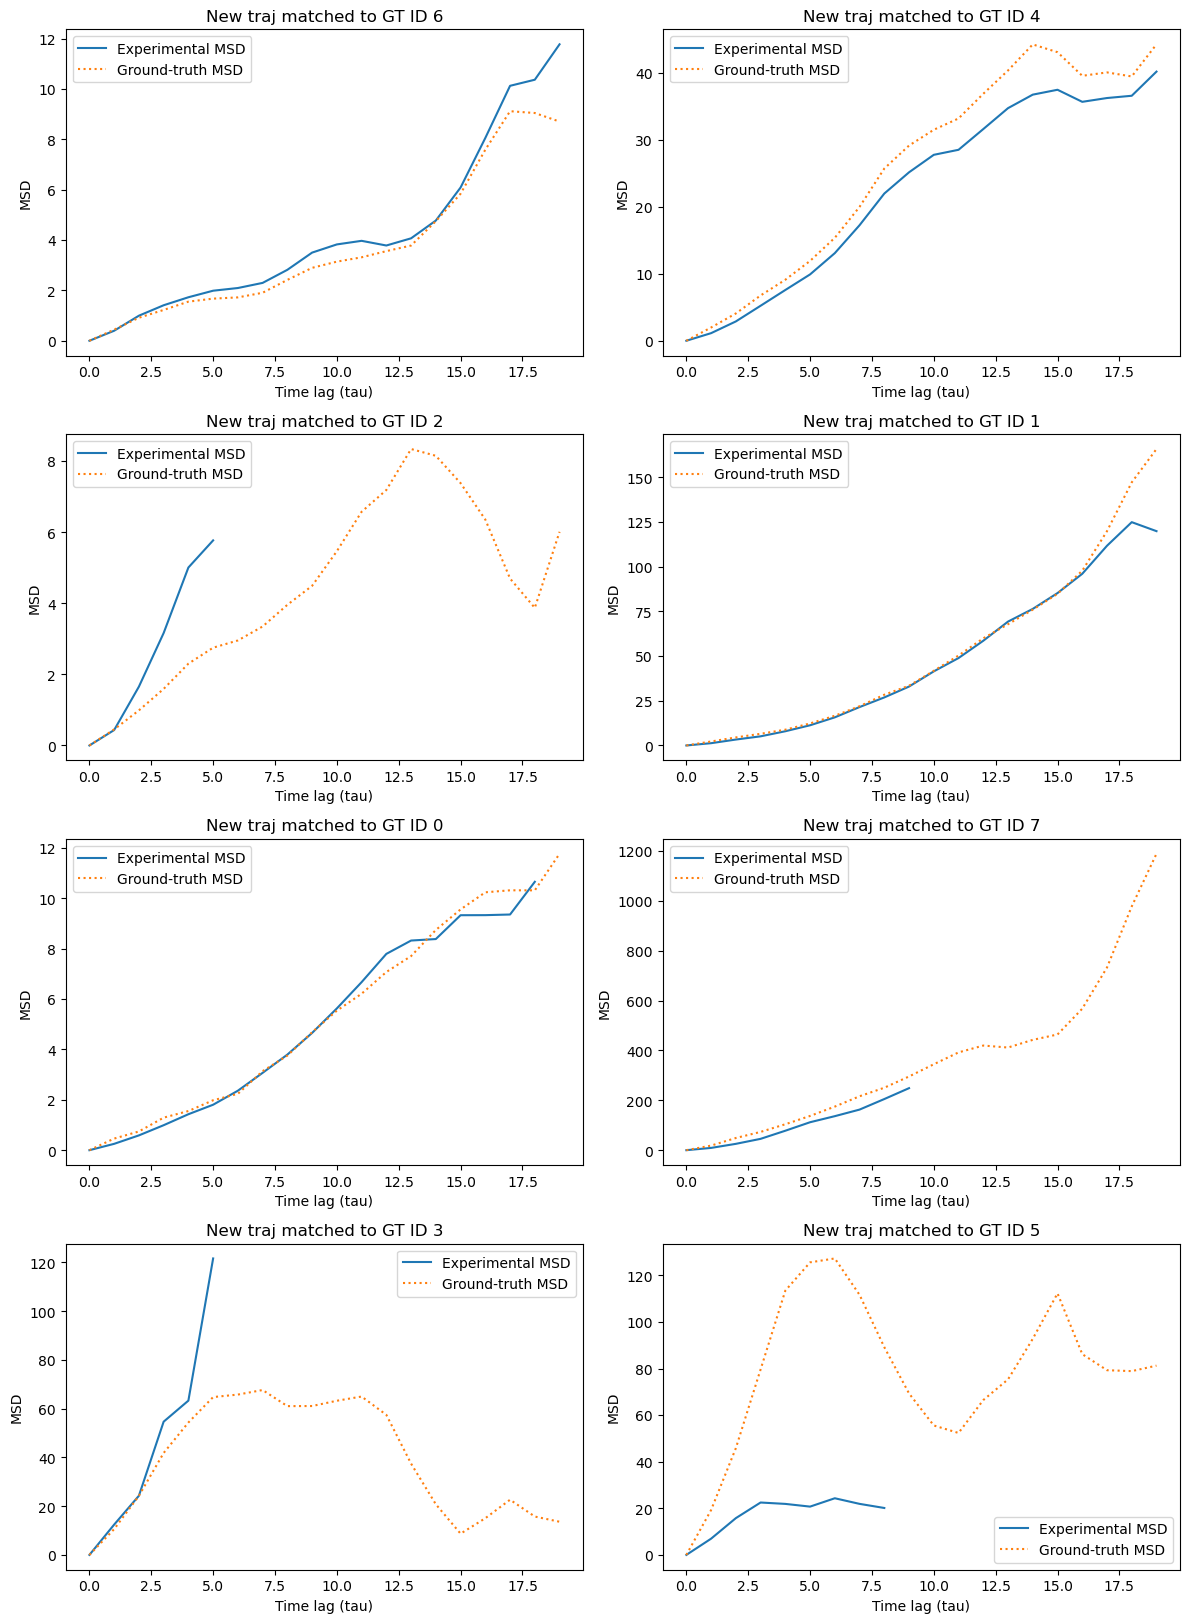

In [ ]:
plot_msd_vs_trajectory_msd(trajectories_localization, trajectories_GT)

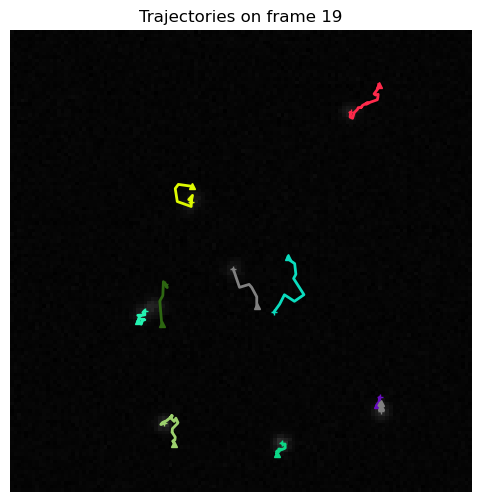

In [ ]:
show_trajectories(frames, trajectories_localization, frame_id=nframes-1)

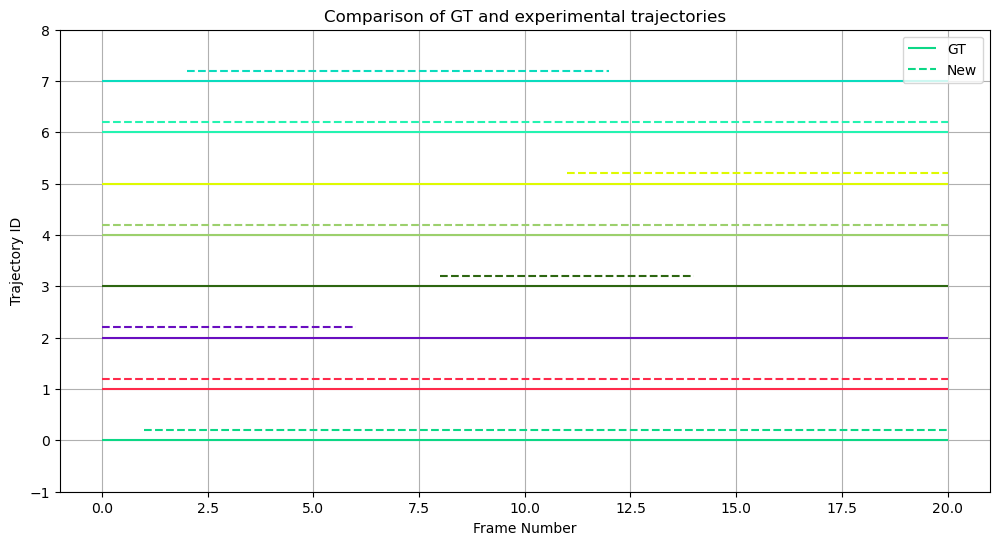

In [ ]:
linear_trajectories_visualizer(trajectories_localization, trajectories_GT)

### New functionality #1: hide static particles

In [ ]:
frames_aniso_hidden = hide_immobile_trajectories(frames, trajectories_localization, bg_mean=image_props["background_intensity"][0], bg_std=image_props["background_intensity"][1])

Hiding trajectory 6 with D1=0.131, D2=0.068
Hiding trajectory 0 with D1=0.075, D2=0.051
Hiding trajectory -1 with D1=0.102, D2=0.026
Hiding trajectory -1 with D1=0.060, D2=0.024


In [ ]:
animate_video(frames, interval=100)

In [ ]:
animate_video(frames_aniso_hidden, interval=100)

### New functionality #2: patch extraction to feed to MiViT

In [ ]:
def extract_patches_per_id(frames, traj, patch_size=11):
    half = patch_size // 2
    patches = []

    # iterate over (frame index, position)
    for frame_idx, pos in zip(traj.frames(), traj.positions):
        y, x = int(pos[0]), int(pos[1])

        # extract patch
        patch = frames[
            frame_idx,
            y-half:y+half+1,
            x-half:x+half+1
        ]

        # skip if patch is incomplete (near borders)
        if patch.shape != (patch_size, patch_size):
            continue

        patches.append(patch)

    return np.array(patches)

In [ ]:
# for all trajectorires ids
def extract_patches(frames, trajectories, patch_size=11):
    patches_list = []

    for traj in trajectories:
        patches_traj = extract_patches_per_id(
            frames, traj, patch_size=patch_size   # pass traj object directly
        )
        patches_list.append((traj.id, patches_traj))

    # Determine max length
    max_len = max(len(p) for _, p in patches_list)

    # Prepare padded array
    padded = np.zeros(
        (len(patches_list), max_len, patch_size, patch_size),
        dtype=patches_list[0][1][0].dtype
    )

    ids = []

    for i, (traj_id, traj_patches) in enumerate(patches_list):
        ids.append(traj_id)
        L = len(traj_patches)
        padded[i, :L] = traj_patches

    return padded, ids

patches, patch_ids = extract_patches(frames, trajectories_localization)

In [ ]:
print(len(trajectories_localization[7].positions))

def visualize_particle_patches(patches, traj_id=None):
    # Remove padded frames
    mask = patches.sum(axis=(1,2)) > 0
    real_patches = patches[mask]
    print(f"Visualizing {real_patches.shape[0]} patches for trajectory ID {traj_id}")

    nframes = real_patches.shape[0]
    fig, axes = plt.subplots(1, nframes, figsize=(2*nframes, 3))
    axes = np.atleast_1d(axes)

    for j in range(nframes):
        axes[j].imshow(real_patches[j], cmap='gray')
        title = f"Frame {j}"
        axes[j].set_title(title)
        axes[j].axis('off')

    plt.suptitle(f"Trajectory ID: {traj_id}")
    plt.tight_layout()
    plt.show()
    

6


Visualizing 20 patches for trajectory ID 1


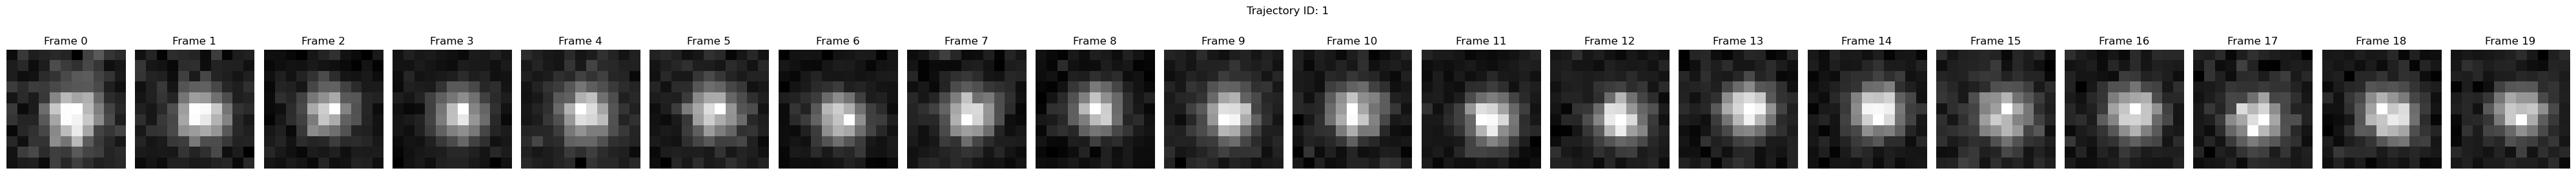

In [ ]:
patches, patch_ids = extract_patches(frames, trajectories_localization)

i = 3  # list index
traj_id = patch_ids[i]

visualize_particle_patches(patches[i], traj_id=traj_id)